# Weekend Coverage Gap Analysis
## Hertz Insurance Replacement - Quantifying the Weekend Opportunity

### Business Context
Hertz operates from **Monday morning until Saturday mid-day**. This means:
- **Operational hours**: Monday 00:00 - Saturday 12:00
- **Closed period**: Saturday 12:00 - Sunday 23:59

### The Problem
Accidents happen 7 days a week. When insurance partners send leads via EDI during closed hours:
1. Leads accumulate over the weekend
2. By Monday morning, customers have already made alternative plans:
   - Borrowed from neighbors/relatives
   - Went to competitors who are open weekends (Enterprise, National)
   - Decided to wait and deal with the inconvenience

### Key Questions
1. What is the conversion rate delta for weekend vs weekday reservations?
2. How many rentals are we leaving on the table?
3. Which segments are most affected?
4. What would be the ROI of weekend coverage?

---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Hertz brand colors (from visual-guide.md)
HERTZ_YELLOW = '#F5C400'   # Primary highlight
CHARCOAL = '#1A1A1A'       # Text, axes
DARK_GRAY = '#6E6E6E'      # Secondary series / comparison
LIGHT_GRAY = '#E6E6E6'     # Gridlines / baselines
TERTIARY_GRAY = '#BDBDBD'  # Tertiary series
POSITIVE_GREEN = '#2E7D32' # Improvements
NEGATIVE_RED = '#C62828'   # Declines (use sparingly, only for negative deltas)
AXIS_TEXT = '#4A4A4A'      # Axis labels

def apply_hertz_style(ax, title='', ylabel='', xlabel=''):
    """Apply Hertz visual guide styling to an axis."""
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=12, fontweight='bold', color=CHARCOAL, pad=10)
    ax.set_ylabel(ylabel, fontweight='bold', color=AXIS_TEXT)
    ax.set_xlabel(xlabel, fontweight='bold', color=AXIS_TEXT)
    
    # Horizontal gridlines only, light gray
    ax.grid(axis='y', color=LIGHT_GRAY, linewidth=0.5)
    ax.grid(axis='x', visible=False)
    ax.set_axisbelow(True)
    
    # Remove or make subtle axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(LIGHT_GRAY)
    
    # Axis text color
    ax.tick_params(colors=AXIS_TEXT)

print("Setup complete.")

Setup complete.


In [2]:
# Load the data
df = pd.read_excel('../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx', engine='openpyxl')

# Clean column names (remove leading newlines from Excel formatting)
df.columns = df.columns.str.strip().str.replace('\n', '')

# Parse dates and create time features
df['INIT_DATE'] = pd.to_datetime(df['INIT_DATE'])
df['day_of_week'] = df['INIT_DATE'].dt.day_name()
df['day_num'] = df['INIT_DATE'].dt.dayofweek  # Monday=0, Sunday=6
df['is_weekend'] = df['day_num'] >= 5
df['week_of_year'] = df['INIT_DATE'].dt.isocalendar().week

print(f"Data loaded: {len(df):,} records")
print(f"Date range: {df['INIT_DATE'].min().date()} to {df['INIT_DATE'].max().date()}")
print(f"\nColumns: {df.columns.tolist()}")

Data loaded: 68,360 records
Date range: 2025-11-01 to 2025-12-31

Columns: ['CONFIRM_NUM', 'RENTER_LAST', 'CLAIM', 'CDP', 'CDP NAME', 'Week Of', 'INIT_DATE', '4 loC', 'HTZREGION', 'SET_STATE', 'ZONE', 'AREA_MGR', 'GENERAL_MGR', 'RENT_LOC', 'RES_ID', 'RENT_IND', 'CANCEL_ID', 'UNUSED_IND', 'CONTACT_GROUP', 'New Contact Group', 'CONTACT RANGE', 'ADJ LNAME', 'ADJ FNAME', 'BODY SHOP', 'CODE', 'KNUM', 'MONTH', 'ZIP', 'CANCEL REASON', 'INIT_DT_FINAL', 'DT_FROM_ALPHA1', 'DAY_DIF', 'HRS_DIF', 'MIN_DIF', 'MMR', 'day_of_week', 'day_num', 'is_weekend', 'week_of_year']


In [3]:
# Quick data overview
print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Total leads (RES_ID sum): {df['RES_ID'].sum():,}")
print(f"Total conversions (RENT_IND sum): {df['RENT_IND'].sum():,}")
print(f"Overall conversion rate: {df['RENT_IND'].sum() / df['RES_ID'].sum() * 100:.2f}%")
print(f"\nCancellations: {df['CANCEL_ID'].sum():,}")
print(f"Unused: {df['UNUSED_IND'].sum():,}")

DATA OVERVIEW
Total leads (RES_ID sum): 68,360
Total conversions (RENT_IND sum): 41,371
Overall conversion rate: 60.52%

Cancellations: 13,702
Unused: 13,301


---
## 2. Conversion by Day of Week

In [4]:
# Aggregate by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

by_day = df.groupby('day_of_week').agg(
    total_leads=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    cancellations=('CANCEL_ID', 'sum'),
    unused=('UNUSED_IND', 'sum')
).reindex(day_order)

by_day['conversion_rate'] = (by_day['conversions'] / by_day['total_leads'] * 100).round(2)
by_day['cancel_rate'] = (by_day['cancellations'] / by_day['total_leads'] * 100).round(2)
by_day['pct_of_leads'] = (by_day['total_leads'] / by_day['total_leads'].sum() * 100).round(1)

print("CONVERSION BY DAY OF WEEK")
print("="*80)
print(by_day[['total_leads', 'conversions', 'conversion_rate', 'cancel_rate', 'pct_of_leads']])

CONVERSION BY DAY OF WEEK
             total_leads  conversions  conversion_rate  cancel_rate  \
day_of_week                                                           
Monday             17367        11133            64.10        18.82   
Tuesday            14088         8600            61.04        18.85   
Wednesday          12296         7314            59.48        18.85   
Thursday            9126         5680            62.24        20.95   
Friday             10517         6203            58.98        20.85   
Saturday            2827         1357            48.00        29.50   
Sunday              2139         1084            50.68        24.31   

             pct_of_leads  
day_of_week                
Monday               25.4  
Tuesday              20.6  
Wednesday            18.0  
Thursday             13.3  
Friday               15.4  
Saturday              4.1  
Sunday                3.1  


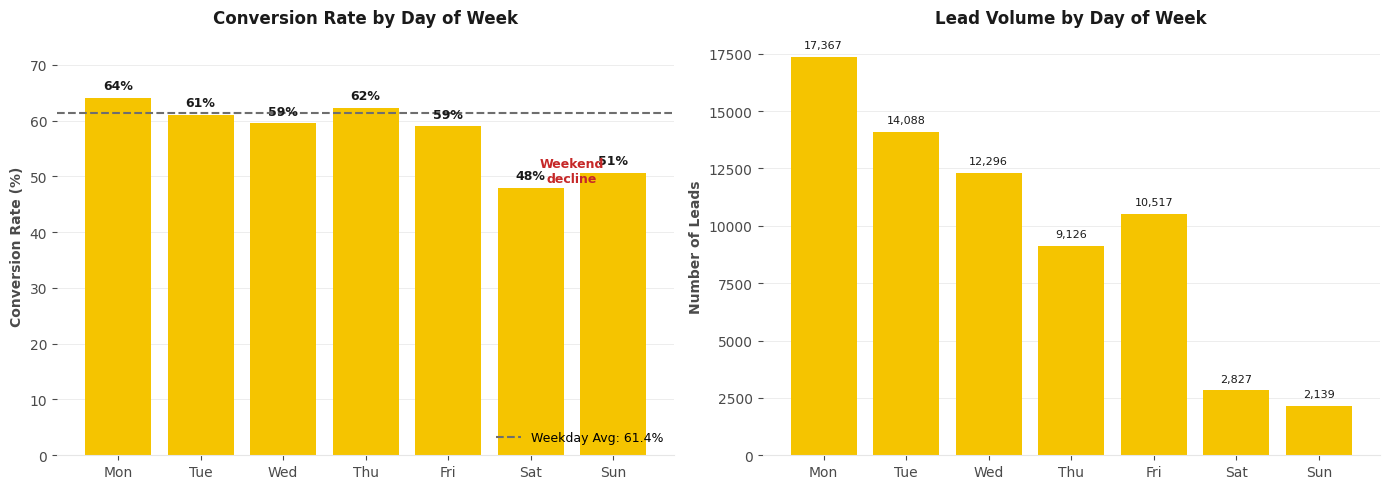

In [5]:
# Visualization: Conversion rate and lead volume by day
# Following visual guide: Yellow for primary, Dark Gray for secondary comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.set_facecolor('white')

short_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_avg = df[~df['is_weekend']]['RENT_IND'].sum() / df[~df['is_weekend']]['RES_ID'].sum() * 100

# Left: Conversion rate - all bars in Yellow (primary metric)
ax1 = axes[0]
bars1 = ax1.bar(short_days, by_day['conversion_rate'], color=HERTZ_YELLOW, edgecolor='none')
ax1.axhline(y=weekday_avg, color=DARK_GRAY, linestyle='--', linewidth=1.5, label=f'Weekday Avg: {weekday_avg:.1f}%')
apply_hertz_style(ax1, title='Conversion Rate by Day of Week', ylabel='Conversion Rate (%)')
ax1.set_ylim(0, 75)
ax1.legend(loc='lower right', frameon=False, fontsize=9)

# Add value labels
for bar, val in zip(bars1, by_day['conversion_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=CHARCOAL)

# Annotate weekend decline with red text (not red bars)
ax1.annotate('Weekend\ndecline', xy=(5.5, 49), fontsize=9, ha='center', color=NEGATIVE_RED, fontweight='bold')

# Right: Lead volume - all bars in Yellow
ax2 = axes[1]
bars2 = ax2.bar(short_days, by_day['total_leads'], color=HERTZ_YELLOW, edgecolor='none')
apply_hertz_style(ax2, title='Lead Volume by Day of Week', ylabel='Number of Leads')

for bar, val in zip(bars2, by_day['total_leads']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, 
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8, color=CHARCOAL)

plt.tight_layout()
plt.show()

---
## 3. Weekend vs Weekday Comparison

In [6]:
# Calculate period-level stats
period_stats = df.groupby('is_weekend').agg(
    total_leads=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    cancellations=('CANCEL_ID', 'sum')
)
period_stats.index = ['Weekday (Mon-Fri)', 'Weekend (Sat-Sun)']
period_stats['conversion_rate'] = (period_stats['conversions'] / period_stats['total_leads'] * 100).round(2)
period_stats['cancel_rate'] = (period_stats['cancellations'] / period_stats['total_leads'] * 100).round(2)
period_stats['pct_of_leads'] = (period_stats['total_leads'] / period_stats['total_leads'].sum() * 100).round(1)

print("WEEKDAY vs WEEKEND COMPARISON")
print("="*70)
print(period_stats)

weekday_rate = period_stats.loc['Weekday (Mon-Fri)', 'conversion_rate']
weekend_rate = period_stats.loc['Weekend (Sat-Sun)', 'conversion_rate']
delta = weekday_rate - weekend_rate

print(f"\n*** CONVERSION GAP: {delta:.2f} percentage points ***")
print(f"    Weekday: {weekday_rate:.1f}%")
print(f"    Weekend: {weekend_rate:.1f}%")

WEEKDAY vs WEEKEND COMPARISON
                   total_leads  conversions  cancellations  conversion_rate  \
Weekday (Mon-Fri)        63394        38930          12348            61.41   
Weekend (Sat-Sun)         4966         2441           1354            49.15   

                   cancel_rate  pct_of_leads  
Weekday (Mon-Fri)        19.48          92.7  
Weekend (Sat-Sun)        27.27           7.3  

*** CONVERSION GAP: 12.26 percentage points ***
    Weekday: 61.4%
    Weekend: 49.1%


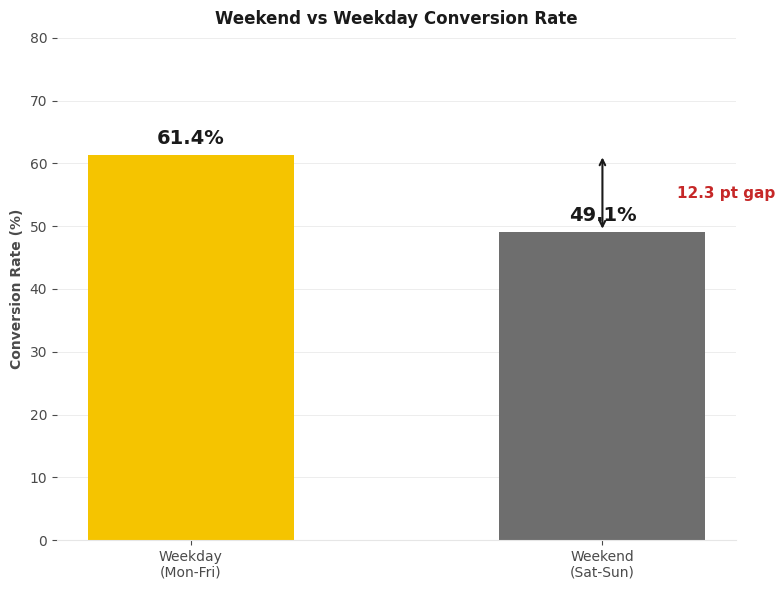

In [7]:
# Visualization: Weekend vs Weekday comparison
# Using Yellow (primary/weekday) and Dark Gray (comparison/weekend)

fig, ax = plt.subplots(figsize=(8, 6))
fig.set_facecolor('white')

periods = ['Weekday\n(Mon-Fri)', 'Weekend\n(Sat-Sun)']
rates = [weekday_rate, weekend_rate]
colors = [HERTZ_YELLOW, DARK_GRAY]  # Primary vs comparison

bars = ax.bar(periods, rates, color=colors, edgecolor='none', width=0.5)
apply_hertz_style(ax, title='Weekend vs Weekday Conversion Rate', ylabel='Conversion Rate (%)')
ax.set_ylim(0, 80)

# Add value labels
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold', color=CHARCOAL)

# Add delta annotation - use red text for the negative delta
ax.annotate('', xy=(1, weekday_rate), xytext=(1, weekend_rate),
            arrowprops=dict(arrowstyle='<->', color=CHARCOAL, lw=1.5))
ax.text(1.18, (weekday_rate + weekend_rate)/2, f'{delta:.1f} pt gap', 
        fontsize=11, fontweight='bold', color=NEGATIVE_RED, va='center')

plt.tight_layout()
plt.show()

### Saturday: The Partial Story

Since Hertz is open Saturday morning (until mid-day), Saturday's 48% conversion rate is a **blend** of:
- Morning leads (converted at ~61% weekday rate)
- Afternoon leads (converted at closed-period rate)

If we assume EDI sends leads evenly throughout the day, we can estimate the true closed-period rate.

In [8]:
# Estimate Saturday PM conversion rate
sat_rate = by_day.loc['Saturday', 'conversion_rate']
sun_rate = by_day.loc['Sunday', 'conversion_rate']

# If Saturday AM = weekday rate and blended = sat_rate:
# 0.5 * weekday_rate + 0.5 * sat_pm_rate = sat_rate
# sat_pm_rate = 2 * sat_rate - weekday_rate
sat_pm_estimate = 2 * sat_rate - weekday_avg

print("ESTIMATING TRUE CLOSED-PERIOD CONVERSION RATE")
print("="*60)
print(f"Saturday blended rate: {sat_rate:.1f}%")
print(f"Sunday rate (all closed): {sun_rate:.1f}%")
print(f"")
print(f"Assuming Saturday AM converts at weekday rate ({weekday_avg:.1f}%):")
print(f"  Estimated Saturday PM rate: {sat_pm_estimate:.1f}%")
print(f"")
print(f"*** The true closed-period rate may be as low as {sat_pm_estimate:.1f}% ***")
print(f"    (Saturday afternoon appears to perform worse than Sunday)")

ESTIMATING TRUE CLOSED-PERIOD CONVERSION RATE
Saturday blended rate: 48.0%
Sunday rate (all closed): 50.7%

Assuming Saturday AM converts at weekday rate (61.4%):
  Estimated Saturday PM rate: 34.6%

*** The true closed-period rate may be as low as 34.6% ***
    (Saturday afternoon appears to perform worse than Sunday)


---
## 4. Opportunity Sizing

In [9]:
# Current state
weekend_leads = period_stats.loc['Weekend (Sat-Sun)', 'total_leads']
weekend_conversions = period_stats.loc['Weekend (Sat-Sun)', 'conversions']
total_leads = df['RES_ID'].sum()
total_conversions = df['RENT_IND'].sum()

# Scenario calculations
scenarios = {
    'Conservative (Match Friday)': by_day.loc['Friday', 'conversion_rate'],
    'Realistic (Close 50% Gap)': weekend_rate + (weekday_rate - weekend_rate) * 0.5,
    'Maximum (Match Weekday)': weekday_rate
}

print("OPPORTUNITY SIZING (Nov-Dec 2025)")
print("="*70)
print(f"Total leads: {total_leads:,}")
print(f"Total conversions: {total_conversions:,}")
print(f"Weekend leads: {weekend_leads:,} ({weekend_leads/total_leads*100:.1f}% of total)")
print(f"Current weekend conversions: {weekend_conversions:,} ({weekend_rate:.1f}%)")
print(f"Weekday benchmark: {weekday_rate:.1f}%")
print(f"Gap: {delta:.1f} percentage points")
print()

results = []
for name, target_rate in scenarios.items():
    uplift_pts = target_rate - weekend_rate
    potential_conv = weekend_leads * (target_rate / 100)
    additional_conv = potential_conv - weekend_conversions
    pct_of_total_leads = additional_conv / total_leads * 100  # % of total leads
    results.append({
        'Scenario': name,
        'Target Rate': target_rate,
        'Uplift (pts)': uplift_pts,
        'Additional Conversions': additional_conv,
        'Pct of Total Leads': pct_of_total_leads
    })
    print(f"{name}:")
    print(f"  Target rate: {target_rate:.1f}%")
    print(f"  Uplift: +{uplift_pts:.1f} pts on weekend leads")
    print(f"  Additional conversions: +{additional_conv:.0f} ({pct_of_total_leads:.1f}% of total leads)")
    print()

scenario_df = pd.DataFrame(results)
scenario_df

OPPORTUNITY SIZING (Nov-Dec 2025)
Total leads: 68,360
Total conversions: 41,371
Weekend leads: 4,966 (7.3% of total)
Current weekend conversions: 2,441 (49.1%)
Weekday benchmark: 61.4%
Gap: 12.3 percentage points

Conservative (Match Friday):
  Target rate: 59.0%
  Uplift: +9.8 pts on weekend leads
  Additional conversions: +488 (0.7% of total leads)

Realistic (Close 50% Gap):
  Target rate: 55.3%
  Uplift: +6.1 pts on weekend leads
  Additional conversions: +304 (0.4% of total leads)

Maximum (Match Weekday):
  Target rate: 61.4%
  Uplift: +12.3 pts on weekend leads
  Additional conversions: +609 (0.9% of total leads)



,Scenario,Target Rate,Uplift (pts),Additional Conversions,Pct of Total Leads
0,Conservative (Match Friday),58.98,9.83,487.9468,0.713790
1,Realistic (Close 50% Gap),55.28,6.13,304.2048,0.445004
2,Maximum (Match Weekday),61.41,12.26,608.6206,0.890317


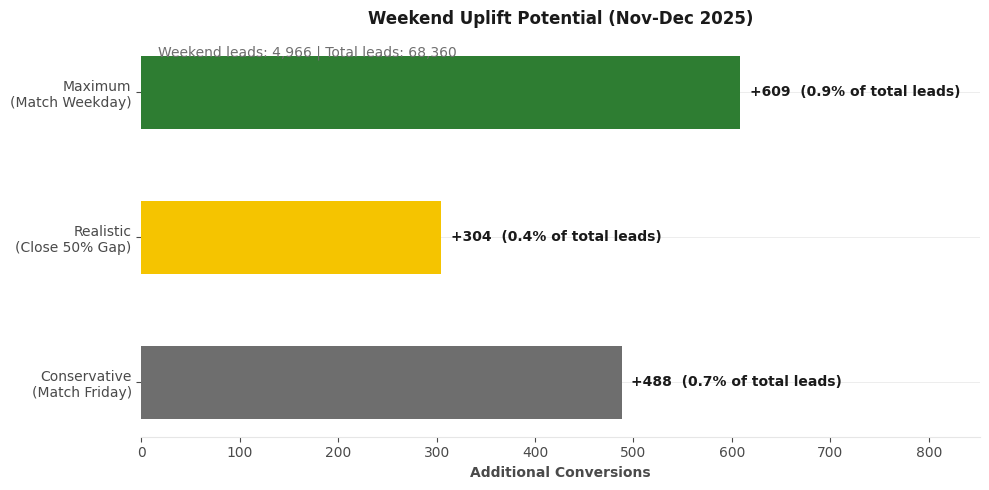

In [10]:
# Visualization: Opportunity sizing - additional conversions with % of total leads
fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor('white')

scenario_names = ['Conservative\n(Match Friday)', 'Realistic\n(Close 50% Gap)', 'Maximum\n(Match Weekday)']
additional_conv = [r['Additional Conversions'] for r in results]
bar_colors = [DARK_GRAY, HERTZ_YELLOW, POSITIVE_GREEN]

bars = ax.barh(scenario_names, additional_conv, color=bar_colors, edgecolor='none', height=0.5)
apply_hertz_style(ax, title='Weekend Uplift Potential (Nov-Dec 2025)', xlabel='Additional Conversions')
ax.set_xlim(0, max(additional_conv) * 1.4)

for bar, val, res in zip(bars, additional_conv, results):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, 
            f'+{val:.0f}  ({res["Pct of Total Leads"]:.1f}% of total leads)', ha='left', va='center', 
            fontsize=10, fontweight='bold', color=CHARCOAL)

# Add context annotation
ax.text(0.02, 0.98, f'Weekend leads: {weekend_leads:,.0f} | Total leads: {total_leads:,}', 
        transform=ax.transAxes, fontsize=10, va='top', color=DARK_GRAY)

plt.tight_layout()
plt.show()

---
## 5. Weekend Analysis by Region/Zone

In [11]:
# Analyze weekend gap by region
def calc_weekend_gap(group):
    weekday = group[~group['is_weekend']]
    weekend = group[group['is_weekend']]
    
    weekday_rate = weekday['RENT_IND'].sum() / weekday['RES_ID'].sum() * 100 if weekday['RES_ID'].sum() > 0 else 0
    weekend_rate = weekend['RENT_IND'].sum() / weekend['RES_ID'].sum() * 100 if weekend['RES_ID'].sum() > 0 else 0
    
    return pd.Series({
        'weekday_leads': weekday['RES_ID'].sum(),
        'weekend_leads': weekend['RES_ID'].sum(),
        'weekday_rate': weekday_rate,
        'weekend_rate': weekend_rate,
        'gap': weekday_rate - weekend_rate,
        'weekend_conversions': weekend['RENT_IND'].sum()
    })

# By Region
by_region = df.groupby('HTZREGION').apply(calc_weekend_gap).reset_index()
by_region = by_region[by_region['weekend_leads'] >= 50]  # Filter for meaningful sample size
by_region = by_region.sort_values('gap', ascending=False)

print("WEEKEND GAP BY REGION (min 50 weekend leads)")
print("="*80)
print(by_region.to_string(index=False))

WEEKEND GAP BY REGION (min 50 weekend leads)
HTZREGION  weekday_leads  weekend_leads  weekday_rate  weekend_rate       gap  weekend_conversions
 LICENSEE         4000.0          216.0     68.225000     37.500000 30.725000                 81.0
  EASTERN        26024.0         2116.0     62.891946     50.000000 12.891946               1058.0
  CENTRAL        19870.0         1647.0     61.595370     50.273224 11.322146                828.0
  WESTERN        11430.0          945.0     58.433946     48.677249  9.756697                460.0


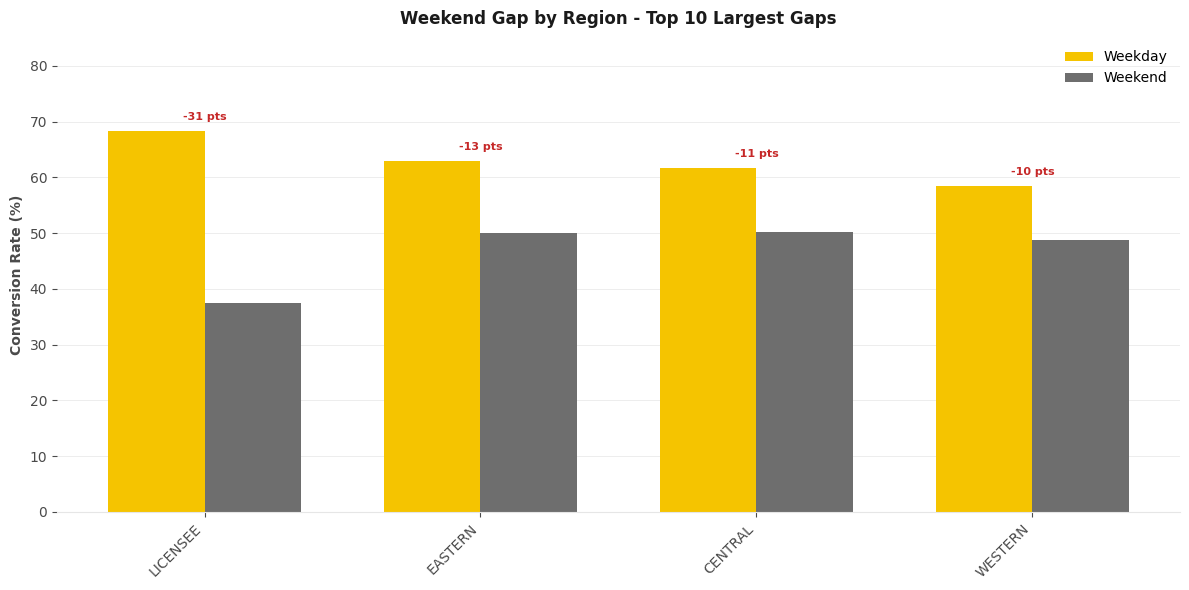

In [12]:
# Visualize top regions with largest weekend gap
# Using Yellow (weekday/primary) and Dark Gray (weekend/comparison)

top_regions = by_region.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('white')

x = np.arange(len(top_regions))
width = 0.35

bars1 = ax.bar(x - width/2, top_regions['weekday_rate'], width, label='Weekday', color=HERTZ_YELLOW, edgecolor='none')
bars2 = ax.bar(x + width/2, top_regions['weekend_rate'], width, label='Weekend', color=DARK_GRAY, edgecolor='none')

apply_hertz_style(ax, title='Weekend Gap by Region - Top 10 Largest Gaps', ylabel='Conversion Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(top_regions['HTZREGION'], rotation=45, ha='right')
ax.legend(frameon=False, loc='upper right')
ax.set_ylim(0, 85)

# Add gap labels in red (showing the decline)
for i, (_, row) in enumerate(top_regions.iterrows()):
    ax.text(i, max(row['weekday_rate'], row['weekend_rate']) + 2, 
            f"-{row['gap']:.0f} pts", ha='center', fontsize=8, color=NEGATIVE_RED, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Calculate opportunity by region
by_region['potential_at_weekday'] = by_region['weekend_leads'] * by_region['weekday_rate'] / 100
by_region['missed_conversions'] = by_region['potential_at_weekday'] - by_region['weekend_conversions']
by_region['annualized_missed'] = by_region['missed_conversions'] * 6

print("OPPORTUNITY BY REGION (Annualized)")
print("="*80)
region_opp = by_region[['HTZREGION', 'weekend_leads', 'gap', 'missed_conversions', 'annualized_missed']]
region_opp = region_opp.sort_values('annualized_missed', ascending=False)
print(region_opp.head(15).to_string(index=False))
print(f"\nTotal annualized opportunity: {region_opp['annualized_missed'].sum():,.0f} rentals")

OPPORTUNITY BY REGION (Annualized)
HTZREGION  weekend_leads       gap  missed_conversions  annualized_missed
  EASTERN         2116.0 12.891946          272.793575        1636.761451
  CENTRAL         1647.0 11.322146          186.475742        1118.854454
  WESTERN          945.0  9.756697           92.200787         553.204724
 LICENSEE          216.0 30.725000           66.366000         398.196000

Total annualized opportunity: 3,707 rentals


---
## 6. Weekend Analysis by Insurance Partner (CDP)

In [14]:
# By CDP
by_cdp = df.groupby('CDP NAME').apply(calc_weekend_gap).reset_index()
by_cdp = by_cdp[by_cdp['weekend_leads'] >= 30]  # Filter for meaningful sample
by_cdp = by_cdp.sort_values('gap', ascending=False)

print("WEEKEND GAP BY INSURANCE PARTNER (min 30 weekend leads)")
print("="*80)
print(by_cdp.head(20).to_string(index=False))

WEEKEND GAP BY INSURANCE PARTNER (min 30 weekend leads)
                   CDP NAME  weekday_leads  weekend_leads  weekday_rate  weekend_rate       gap  weekend_conversions
     STATE FARM-DULUTH HIRS        17201.0         2218.0     56.909482     41.523895 15.385587                921.0
     TESLA INSURANCE CLAIMS         1890.0           41.0     65.978836     58.536585  7.442251                 24.0
     STATE FARM-DUPONT HIRS          448.0           42.0     72.767857     66.666667  6.101190                 28.0
      STATE FARM-TEMPE HIRS        14721.0         1550.0     58.324842     52.709677  5.615165                817.0
         CSAA OKLAHOMA CITY          455.0           50.0     55.824176     52.000000  3.824176                 26.0
   MAPFRE INS GROUP WEBSTER          347.0           79.0      6.916427      5.063291  1.853135                  4.0
     STATE FARM-DALLAS HIRS         2280.0          223.0     74.298246     73.542601  0.755645                164.0
STATE FA

In [15]:
# Calculate opportunity by CDP
by_cdp['potential_at_weekday'] = by_cdp['weekend_leads'] * by_cdp['weekday_rate'] / 100
by_cdp['missed_conversions'] = by_cdp['potential_at_weekday'] - by_cdp['weekend_conversions']
by_cdp['annualized_missed'] = by_cdp['missed_conversions'] * 6

cdp_opp = by_cdp[['CDP NAME', 'weekend_leads', 'weekday_rate', 'weekend_rate', 'gap', 'annualized_missed']]
cdp_opp = cdp_opp.sort_values('annualized_missed', ascending=False)

print("TOP 15 CDPs BY WEEKEND OPPORTUNITY")
print("="*80)
print(cdp_opp.head(15).to_string(index=False))
print(f"\nTotal annualized opportunity across CDPs: {cdp_opp['annualized_missed'].sum():,.0f} rentals")

TOP 15 CDPs BY WEEKEND OPPORTUNITY
                   CDP NAME  weekend_leads  weekday_rate  weekend_rate       gap  annualized_missed
     STATE FARM-DULUTH HIRS         2218.0     56.909482     41.523895 15.385587        2047.513865
      STATE FARM-TEMPE HIRS         1550.0     58.324842     52.709677  5.615165         522.210312
     TESLA INSURANCE CLAIMS           41.0     65.978836     58.536585  7.442251          18.307937
     STATE FARM-DUPONT HIRS           42.0     72.767857     66.666667  6.101190          15.375000
         CSAA OKLAHOMA CITY           50.0     55.824176     52.000000  3.824176          11.472527
     STATE FARM-DALLAS HIRS          223.0     74.298246     73.542601  0.755645          10.110526
   MAPFRE INS GROUP WEBSTER           79.0      6.916427      5.063291  1.853135           8.783862
     AAA ANAHEIM HILLS HIRS           44.0     44.559585     45.454545 -0.894960          -2.362694
STATE FARM-BLOOMINGTON HIRS          137.0     68.808568     69.3

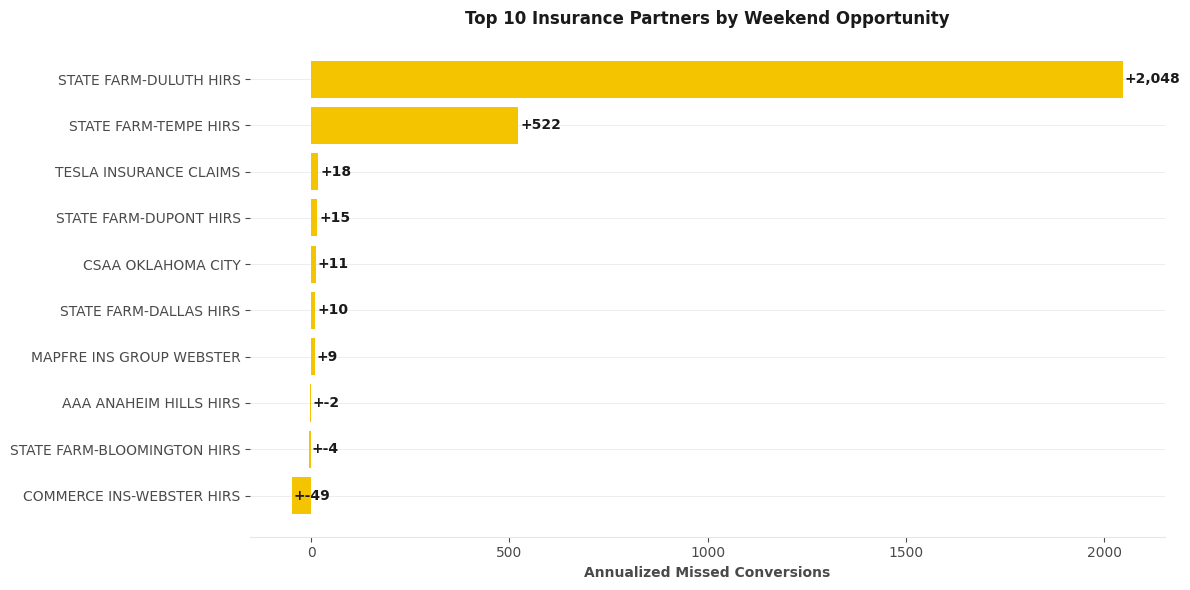

In [16]:
# Visualize top CDPs - Yellow bars (primary metric)
top_cdps = cdp_opp.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('white')

bars = ax.barh(range(len(top_cdps)), top_cdps['annualized_missed'], color=HERTZ_YELLOW, edgecolor='none')
ax.set_yticks(range(len(top_cdps)))
ax.set_yticklabels(top_cdps['CDP NAME'])
ax.invert_yaxis()
apply_hertz_style(ax, title='Top 10 Insurance Partners by Weekend Opportunity', xlabel='Annualized Missed Conversions')

for bar, val in zip(bars, top_cdps['annualized_missed']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, 
            f'+{val:,.0f}', ha='left', va='center', fontsize=10, fontweight='bold', color=CHARCOAL)

plt.tight_layout()
plt.show()

---
## 7. Cancellation Analysis: Why Do Weekend Leads Not Convert?

In [17]:
# Analyze cancellation reasons by weekend vs weekday
cancel_df = df[df['CANCEL_ID'] == 1].copy()

# Cancellation reasons by period
cancel_by_reason = cancel_df.groupby(['is_weekend', 'CANCEL REASON']).size().unstack(fill_value=0)
cancel_by_reason.index = ['Weekday', 'Weekend']

# Convert to percentages
cancel_pct = cancel_by_reason.div(cancel_by_reason.sum(axis=1), axis=0) * 100

print("CANCELLATION REASONS - WEEKEND vs WEEKDAY (% of cancellations)")
print("="*80)
print(cancel_pct.T.round(1))

CANCELLATION REASONS - WEEKEND vs WEEKDAY (% of cancellations)
                           Weekday  Weekend
CANCEL REASON                              
                              74.8     86.5
ALREADY RENTED WITH COMPE      1.2      0.9
COMPANY CANCELLED              0.9      0.1
CREDIT CARD DECLINED           0.0      0.0
CUSTOMER CANCELLED            15.0      9.6
CUSTOMER CHANGE MIND           0.3      0.0
MERGE RESERVATION              3.0      1.3
NEED TO REMOVE CASE 1B CO      0.7      0.3
NO SHOW                        3.8      1.3
Reset to Confirmed Reserv      0.1      0.1
WRONG CONFIRMATION NUMBER      0.0      0.0
customer decided to go to      0.0      0.0
duplicate                      0.0      0.0
x                              0.0      0.0


In [18]:
# Compare cancellation rates
print("\nCANCELLATION RATES BY PERIOD")
print("="*60)

weekday_cancel_rate = df[~df['is_weekend']]['CANCEL_ID'].sum() / df[~df['is_weekend']]['RES_ID'].sum() * 100
weekend_cancel_rate = df[df['is_weekend']]['CANCEL_ID'].sum() / df[df['is_weekend']]['RES_ID'].sum() * 100

print(f"Weekday cancellation rate: {weekday_cancel_rate:.1f}%")
print(f"Weekend cancellation rate: {weekend_cancel_rate:.1f}%")
print(f"Difference: +{weekend_cancel_rate - weekday_cancel_rate:.1f} pts on weekends")


CANCELLATION RATES BY PERIOD
Weekday cancellation rate: 19.5%
Weekend cancellation rate: 27.3%
Difference: +7.8 pts on weekends


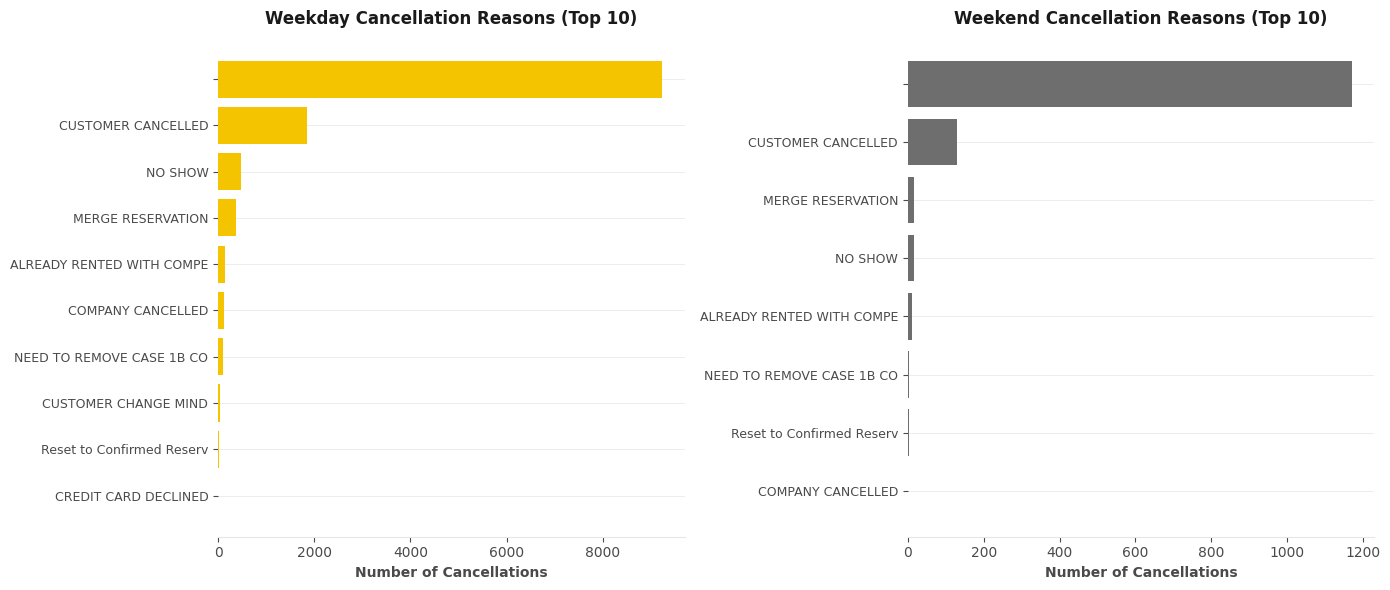

In [19]:
# Top cancellation reasons comparison
# Yellow for primary (weekday), Dark Gray for comparison (weekend)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.set_facecolor('white')

colors_map = {'Weekday': HERTZ_YELLOW, 'Weekend': DARK_GRAY}

for idx, (period, is_wknd) in enumerate([('Weekday', False), ('Weekend', True)]):
    ax = axes[idx]
    period_cancel = cancel_df[cancel_df['is_weekend'] == is_wknd]['CANCEL REASON'].value_counts().head(10)
    
    bars = ax.barh(range(len(period_cancel)), period_cancel.values, color=colors_map[period], edgecolor='none')
    ax.set_yticks(range(len(period_cancel)))
    ax.set_yticklabels(period_cancel.index, fontsize=9)
    ax.invert_yaxis()
    apply_hertz_style(ax, title=f'{period} Cancellation Reasons (Top 10)', xlabel='Number of Cancellations')

plt.tight_layout()
plt.show()

---
## 8. Weekly Trend Analysis

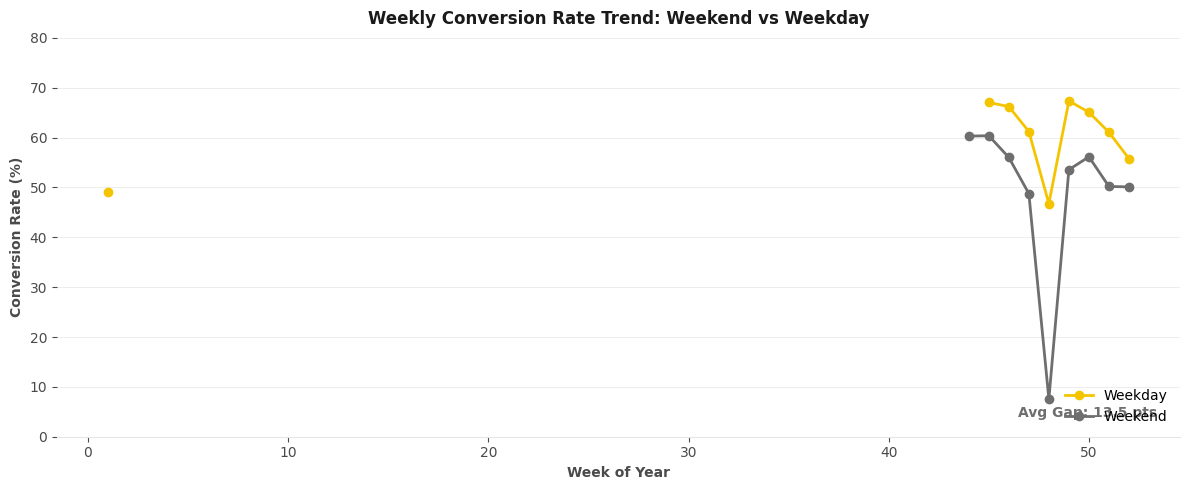

In [20]:
# Weekly conversion rates: weekend vs weekday
weekly = df.groupby(['week_of_year', 'is_weekend']).agg(
    leads=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()

weekly['conversion_rate'] = weekly['conversions'] / weekly['leads'] * 100
weekly['period'] = weekly['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

# Pivot for plotting
weekly_pivot = weekly.pivot(index='week_of_year', columns='period', values='conversion_rate')

fig, ax = plt.subplots(figsize=(12, 5))
fig.set_facecolor('white')

# Yellow line for weekday (primary), Dark Gray for weekend (comparison)
ax.plot(weekly_pivot.index, weekly_pivot['Weekday'], marker='o', color=HERTZ_YELLOW, 
        linewidth=2, markersize=6, label='Weekday')
ax.plot(weekly_pivot.index, weekly_pivot['Weekend'], marker='o', color=DARK_GRAY, 
        linewidth=2, markersize=6, label='Weekend')

apply_hertz_style(ax, title='Weekly Conversion Rate Trend: Weekend vs Weekday', 
                  xlabel='Week of Year', ylabel='Conversion Rate (%)')
ax.legend(frameon=False, loc='lower right')
ax.set_ylim(0, 80)

# Calculate and show average gap
avg_gap = (weekly_pivot['Weekday'] - weekly_pivot['Weekend']).mean()
ax.text(0.98, 0.05, f'Avg Gap: {avg_gap:.1f} pts', transform=ax.transAxes, 
        ha='right', fontsize=10, color=DARK_GRAY, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. Contact Group Analysis on Weekends

In [21]:
# How does contact timing interact with weekend leads?
contact_weekend = df.groupby(['is_weekend', 'CONTACT_GROUP']).agg(
    leads=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()

contact_weekend['conversion_rate'] = contact_weekend['conversions'] / contact_weekend['leads'] * 100
contact_weekend['period'] = contact_weekend['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

# Pivot table
contact_pivot = contact_weekend.pivot(index='CONTACT_GROUP', columns='period', values='conversion_rate')
contact_pivot['Gap'] = contact_pivot['Weekday'] - contact_pivot['Weekend']
contact_pivot = contact_pivot.sort_values('Gap', ascending=False)

print("CONVERSION BY CONTACT GROUP: WEEKEND vs WEEKDAY")
print("="*60)
print(contact_pivot.round(1))

CONVERSION BY CONTACT GROUP: WEEKEND vs WEEKDAY
period         Weekday  Weekend   Gap
CONTACT_GROUP                        
NO CONTACT        41.0      9.8  31.2
HRD - OKC         54.3     47.0   7.3
COUNTER           70.4     64.5   5.9


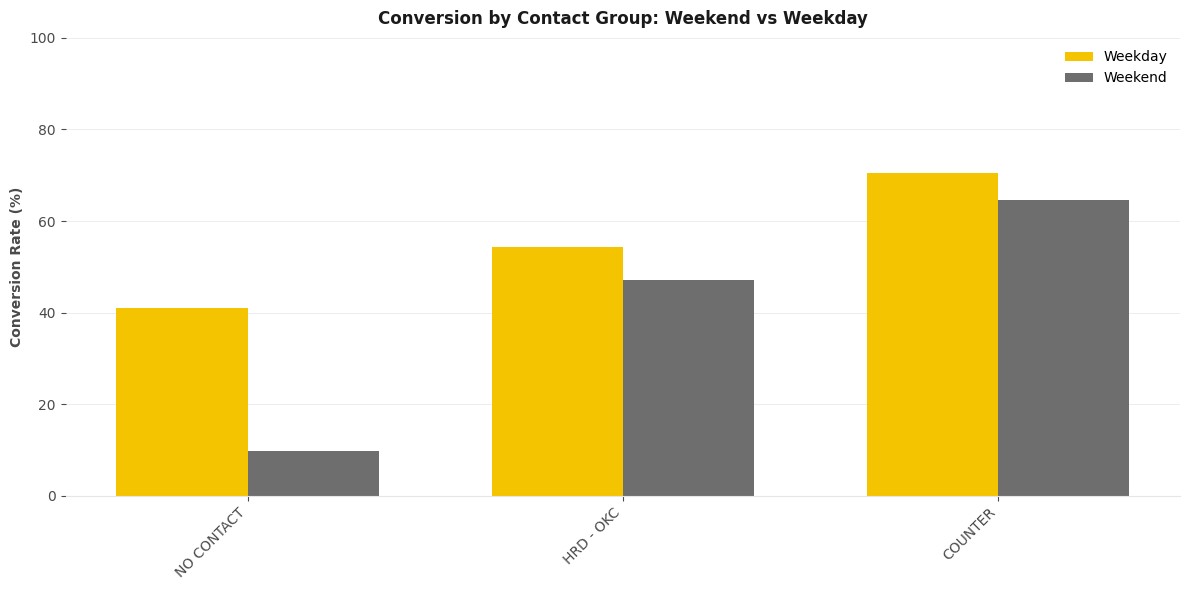

In [22]:
# Visualize contact group gaps
# Yellow (weekday/primary), Dark Gray (weekend/comparison)

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('white')

contact_groups = contact_pivot.index.tolist()
x = np.arange(len(contact_groups))
width = 0.35

bars1 = ax.bar(x - width/2, contact_pivot['Weekday'], width, label='Weekday', color=HERTZ_YELLOW, edgecolor='none')
bars2 = ax.bar(x + width/2, contact_pivot['Weekend'], width, label='Weekend', color=DARK_GRAY, edgecolor='none')

apply_hertz_style(ax, title='Conversion by Contact Group: Weekend vs Weekday', ylabel='Conversion Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(contact_groups, rotation=45, ha='right')
ax.legend(frameon=False, loc='upper right')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

---
## 10. Executive Summary & Recommendations

In [23]:
# Final summary statistics
print("="*70)
print("EXECUTIVE SUMMARY: WEEKEND COVERAGE OPPORTUNITY")
print("="*70)
print()
print("KEY FINDINGS")
print("-"*50)
print(f"1. Weekend conversion rate ({weekend_rate:.1f}%) is {delta:.1f} pts BELOW weekday ({weekday_rate:.1f}%)")
print(f"2. Weekend leads: {weekend_leads:,} ({weekend_leads/total_leads*100:.1f}% of {total_leads:,} total)")
print(f"3. Saturday PM conversion (estimated) may be as low as {sat_pm_estimate:.1f}%")
print(f"4. Weekend cancellation rate is higher than weekday (+7.8 pts)")
print()

print("UPLIFT POTENTIAL (Nov-Dec 2025)")
print("-"*50)
print(f"Total leads: {total_leads:,}")
print()
for r in results:
    print(f"{r['Scenario']}:")
    print(f"  +{r['Additional Conversions']:.0f} conversions ({r['Pct of Total Leads']:.1f}% of total leads)")
print()

print("ROOT CAUSE")
print("-"*50)
print("Leads arrive via EDI on Saturday PM and Sunday.")
print("By Monday morning when we call, customers have:")
print("  - Borrowed from neighbors/relatives")
print("  - Gone to competitors open on weekends")
print("  - Made alternative plans or decided to wait")
print()

print("RECOMMENDATIONS")
print("-"*50)
print("1. Pilot weekend call center coverage (Saturday PM + Sunday)")
print("2. Focus on high-opportunity regions first")
print("3. Partner with top CDPs for weekend-specific SLAs")
print("4. Consider automated confirmation calls/texts for weekend leads")

EXECUTIVE SUMMARY: WEEKEND COVERAGE OPPORTUNITY

KEY FINDINGS
--------------------------------------------------
1. Weekend conversion rate (49.1%) is 12.3 pts BELOW weekday (61.4%)
2. Weekend leads: 4,966 (7.3% of 68,360 total)
3. Saturday PM conversion (estimated) may be as low as 34.6%
4. Weekend cancellation rate is higher than weekday (+7.8 pts)

UPLIFT POTENTIAL (Nov-Dec 2025)
--------------------------------------------------
Total leads: 68,360

Conservative (Match Friday):
  +488 conversions (0.7% of total leads)
Realistic (Close 50% Gap):
  +304 conversions (0.4% of total leads)
Maximum (Match Weekday):
  +609 conversions (0.9% of total leads)

ROOT CAUSE
--------------------------------------------------
Leads arrive via EDI on Saturday PM and Sunday.
By Monday morning when we call, customers have:
  - Borrowed from neighbors/relatives
  - Gone to competitors open on weekends
  - Made alternative plans or decided to wait

RECOMMENDATIONS
-------------------------------------

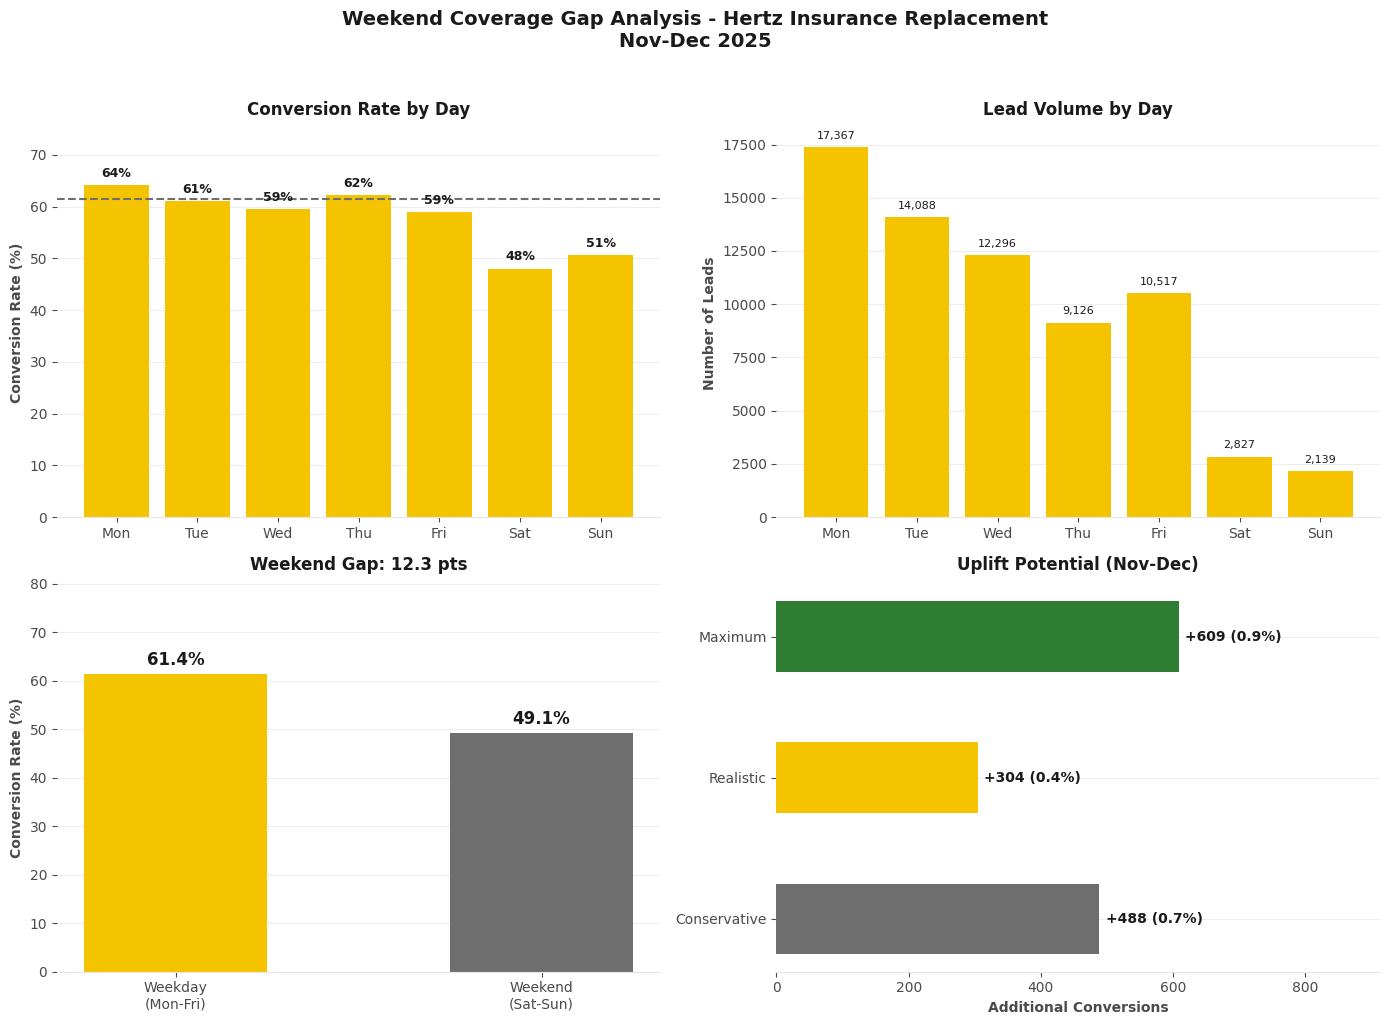


Saved: weekend_coverage_summary.png


In [24]:
# Create final summary visualization following Hertz visual guide
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.set_facecolor('white')

# Top left: Conversion by day - all Yellow bars (primary metric)
ax1 = axes[0, 0]
bars = ax1.bar(short_days, by_day['conversion_rate'], color=HERTZ_YELLOW, edgecolor='none')
ax1.axhline(y=weekday_avg, color=DARK_GRAY, linestyle='--', linewidth=1.5)
apply_hertz_style(ax1, title='Conversion Rate by Day', ylabel='Conversion Rate (%)')
ax1.set_ylim(0, 75)
for bar, val in zip(bars, by_day['conversion_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=CHARCOAL)

# Top right: Lead volume - all Yellow bars
ax2 = axes[0, 1]
bars = ax2.bar(short_days, by_day['total_leads'], color=HERTZ_YELLOW, edgecolor='none')
apply_hertz_style(ax2, title='Lead Volume by Day', ylabel='Number of Leads')
for bar, val in zip(bars, by_day['total_leads']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, 
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8, color=CHARCOAL)

# Bottom left: Gap comparison - Yellow (primary) vs Dark Gray (comparison)
ax3 = axes[1, 0]
periods = ['Weekday\n(Mon-Fri)', 'Weekend\n(Sat-Sun)']
rates = [weekday_rate, weekend_rate]
bars = ax3.bar(periods, rates, color=[HERTZ_YELLOW, DARK_GRAY], edgecolor='none', width=0.5)
apply_hertz_style(ax3, title=f'Weekend Gap: {delta:.1f} pts', ylabel='Conversion Rate (%)')
ax3.set_ylim(0, 80)
for bar, val in zip(bars, rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color=CHARCOAL)

# Bottom right: Additional conversions potential with % of total leads
ax4 = axes[1, 1]
scenario_names = ['Conservative', 'Realistic', 'Maximum']
additional_conv = [r['Additional Conversions'] for r in results]
pct_of_total = [r['Pct of Total Leads'] for r in results]
bars = ax4.barh(scenario_names, additional_conv, color=[DARK_GRAY, HERTZ_YELLOW, POSITIVE_GREEN], edgecolor='none', height=0.5)
apply_hertz_style(ax4, title='Uplift Potential (Nov-Dec)', xlabel='Additional Conversions')
ax4.set_xlim(0, max(additional_conv) * 1.5)
for bar, val, pct in zip(bars, additional_conv, pct_of_total):
    ax4.text(val + 10, bar.get_y() + bar.get_height()/2, 
             f'+{val:.0f} ({pct:.1f}%)', ha='left', va='center', fontsize=10, fontweight='bold', color=CHARCOAL)

fig.suptitle('Weekend Coverage Gap Analysis - Hertz Insurance Replacement\nNov-Dec 2025', 
             fontsize=14, fontweight='bold', color=CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig('weekend_coverage_summary.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()
print("\nSaved: weekend_coverage_summary.png")